<a href="https://colab.research.google.com/github/Abhishek213-013/Gesture_Transformer_NoTime_Idle/blob/main/Gesture_Transformer_NoTime_Idle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn joblib

In [2]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model

In [3]:
with zipfile.ZipFile('/content/initial_data.zip','r') as z:
    z.extractall('/content/dataset1')

with zipfile.ZipFile('/content/data_v2.zip','r') as z:
    z.extractall('/content/dataset2')

**Merge Dataset**

In [4]:
import shutil

final_path = "/content/final_dataset"

if os.path.exists(final_path):
    shutil.rmtree(final_path)

os.makedirs(final_path)

# Copy old classes
for f in os.listdir("/content/dataset1/data"):
    shutil.copytree(
        f"/content/dataset1/data/{f}",
        f"{final_path}/{f}",
        dirs_exist_ok=True
    )

# Add idle class
for f in os.listdir("/content/dataset2/data"):
    shutil.copytree(
        f"/content/dataset2/data/{f}",
        f"{final_path}/{f}",
        dirs_exist_ok=True
    )

**Load Dataset (NO TIME COLUMN)**

In [5]:
X, y = [], []
label_map = {}
window_size = 50
label_index = 0

for gesture in os.listdir(final_path):

    path = os.path.join(final_path, gesture)
    if not os.path.isdir(path):
        continue

    label_map[label_index] = gesture
    print("Loading:", gesture)

    for file in os.listdir(path):
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(path, file))

            # REMOVE TIME COLUMN
            if 'time' in df.columns:
                df = df.drop(columns=['time'])

            df = df.select_dtypes(include=np.number)
            data = df.values

            if len(data) >= window_size:
                X.append(data[:window_size])
                y.append(label_index)

    label_index += 1

X = np.array(X)
y = np.array(y)

print("Shape:", X.shape)
print("Labels:", len(np.unique(y)))
print(label_map)

Loading: right
Loading: down
Loading: up
Loading: left
Loading: idle
Shape: (124, 50, 12)
Labels: 5
{0: 'right', 1: 'down', 2: 'up', 3: 'left', 4: 'idle'}


**Normalize**

In [6]:
samples, t, f = X.shape
X = X.reshape(-1, f)

scaler = StandardScaler()
X = scaler.fit_transform(X)
X = X.reshape(samples, t, f)

**Train/Test Split**

In [7]:
num_classes = len(label_map)
y_cat = to_categorical(y, num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

**Transformer Block**

In [8]:
def transformer_block(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.3):

    attn = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(x, x)

    x = LayerNormalization(epsilon=1e-6)(x + attn)

    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dropout(dropout)(ff)
    ff = Dense(x.shape[-1])(ff)

    return LayerNormalization(epsilon=1e-6)(x + ff)

**Build Model**

In [9]:
inputs = Input(shape=(50, X.shape[-1]))

x = transformer_block(inputs)
x = transformer_block(x)

x = GlobalAveragePooling1D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 12)    │     13,068 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 12)    │          0 │ input_layer[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 50, 12)    │         24 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 128)   │      1,664 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50, 12)    │      1,548 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50, 12)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 12)    │         24 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 12)    │     13,068 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 50, 12)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 12)    │         24 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 50, 128)   │      1,664 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 50, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 50, 12)    │      1,548 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 50, 12)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 12)    │         24 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 12)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      1,664 │ global_average_p

 Total params: 42,901 (167.58 KB)

 Trainable params: 42,901 (167.58 KB)

 Non-trainable params: 0 (0.00 B)

**Early Stopping**

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

**Train Model**

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.3939 - loss: 1.5381 - val_accuracy: 0.7200 - val_loss: 1.3300
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6566 - loss: 1.3156 - val_accuracy: 0.8800 - val_loss: 1.0819
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7273 - loss: 1.1071 - val_accuracy: 0.9600 - val_loss: 0.8492
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7879 - loss: 0.8506 - val_accuracy: 0.8800 - val_loss: 0.6124
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8384 - loss: 0.7018 - val_accuracy: 0.8400 - val_loss: 0.4451
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8687 - loss: 0.4512 - val_accuracy: 1.0000 - val_loss: 0.2992
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9798 - loss: 0.3387 - val_accuracy: 1.0000 - val_loss: 0.1850
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9899 - loss: 0.2359 - val_accuracy: 0.9600 - val_loss: 0.1278
E

**Evaluate**

In [12]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0403
Accuracy: 1.0


**Predictions**

In [13]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 964ms/step


**Confusion Matrix**

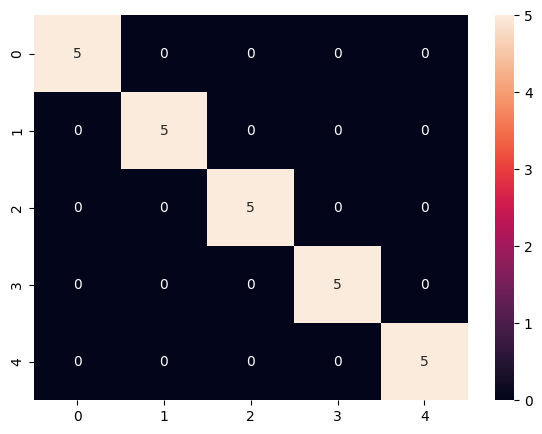

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

**Classification Report**

In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         5

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



**Save Model**

In [16]:
model.save("transformer_idle_model.h5")

**Save Scaler**

In [17]:
import joblib
joblib.dump(scaler, "transformer_scaler.save")

['transformer_scaler.save']